<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/GAN_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative Adversarial Network (GAN)

Uma Generative Adversarial Network (GAN) é composta por dois modelos neurais: o $\textbf{Gerador}$ $G$ e o $\textbf{Discriminador}$ $D$. O objetivo de $G$ é produzir imagens sintéticas que se pareçam com as imagens reais do conjunto de dados, enquanto o objetivo de $D$ é distinguir corretamente entre imagens reais e imagens criadas por $G$.

O treinamento ocorre como um jogo minimax entre os dois modelos, com $G$ tentando enganar $D$, e $D$ tentando não ser enganado.

## 1. Distribuições envolvidas

Seja $p_{\text{data}}(x)$ a distribuição real das imagens do dataset e $p_{z}(z)$ a distribuição de ruído (*noise*) usada para gerar imagens sintéticas. Uma amostra $z$ é transformada em imagem por meio de $G(z)$.

## 2. Função objetivo geral

O treinamento clássico de uma GAN resolve o seguinte problema minimax:

$$
\min_{G} \max_{D} \; V(D,G)
= \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)]
+ \mathbb{E}_{z \sim p_{z}}[\log(1 - D(G(z)))].
$$

O Discriminador $D$ tenta maximizar esta expressão, enquanto o Gerador $G$ tenta minimizá-la.

## 3. Treinamento do Discriminador

Em cada iteração do treinamento, o Discriminador recebe dois tipos de entradas:

1. Imagens reais $x \sim p_{\text{data}}(x)$, para as quais o objetivo é que $D(x)$ seja próximo de $1$;
2. Imagens falsas $G(z)$ geradas pelo Gerador, para as quais o objetivo é que $D(G(z))$ seja próximo de $0$. A função de perda do Discriminador é dada então por:

$$
L_{D} = - \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)]
- \mathbb{E}_{z \sim p_{z}}[\log (1 - D(G(z)))].
$$

**Durante esta etapa, somente os parâmetros de $D$ são atualizados.**

## 4. Treinamento do Gerador

O Gerador tenta produzir imagens que façam o Discriminador acreditar que são reais. Assim, seu objetivo é maximizar a probabilidade de que $D$ classifique $G(z)$ como real. Isso significa minimizar:

$$
L_{G} = \mathbb{E}_{z \sim p_{z}}[\log ( 1 - D(G(z)))].
$$

No entanto, para melhorar a estabilidade do treinamento, normalmente usa-se a versão não saturada, na qual o Gerador maximiza $\log D(G(z))$, equivalente a minimizar:

$$
L_{G}^{\text{NS}} = - \mathbb{E}_{z \sim p_{z}}[\log D(G(z))].
$$

**Durante esta etapa, somente os pesos de $G$ são atualizados.** E isso significa que os pesos de $D$ estão CONGELADOS!

## 5. Ciclo completo de treinamento

Para cada minibatch de dados:

* **Atualiza-se o Discriminador**
  1. amostra-se um batch de imagens reais $\{x_i\}$;
  2. amostra-se ruídos $\{z_i\}$ e gera-se imagens falsas $\{G(z_i)\}$;
  3. calcula-se $L_D$ e atualizam-se os parâmetros de $D$.

* **Atualiza-se o Gerador**
  1. amostra-se novo ruído $\{z_i\}$;
  2. gera-se imagens $\{G(z_i)\}$;
  3. calcula-se $L_G$ ou $L_G^{\text{NS}}$;
  4. atualizam-se os parâmetros de $G$.

Este processo é repetido até que o Gerador produza imagens suficientemente realistas e o Discriminador não consiga distingui-las de imagens reais com facilidade.







# Hard to Train

Já demonstraram que uma
GAN só pode atingir um único equilíbrio de Nash: isso ocorre quando o gerador produz
imagens perfeitamente realistas e o discriminador é forçado a adivinhar (50% real, 50%
falso). Esse fato é encorajador: basta treinar a
GAN por tempo suficiente e ela eventualmente atingirá esse equilíbrio, fornecendo um gerador perfeito. Infelizmente, nada garante que o equilíbrio será atingido.

O problema mais comum é o *mode collapse* do treinamento.

# Exemplo

Veja também um exemplo DGAN com o Fashion MNIST nas leituras complementares.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar e Pré-processar o Dataset MNIST
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

# Normalizar os pixels para o intervalo [-1, 1] (comum para GANs)
x_train = x_train.astype("float32") / 127.5 - 1

# Redimensionar as imagens para o formato (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

print(f"Formato dos dados de treino: {x_train.shape}")

# Tamanho do vetor de ruído (latente)
latent_dim = 100

# 2. Construir o Gerador
def build_generator():
    model = keras.Sequential(name="generator")
    # Entrada: vetor de ruído (latent_dim)
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256) # None para o tamanho do batch

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"))
    assert model.output_shape == (None, 28, 28, 1)

    return model

generator = build_generator()
generator.summary()

# 3. Construir o Discriminador
def build_discriminator():
    model = keras.Sequential(name="discriminator")
    # Entrada: imagem de 28x28x1
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same", input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid")) # Saída binária (real/falso)

    return model

discriminator = build_discriminator()
discriminator.summary()

# 4. Definir Funções de Perda e Otimizadores

cross_entropy = keras.losses.BinaryCrossentropy(from_logits=False) # from_logits=False pois o Discriminador usa sigmoid

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    # O Gerador quer que o Discriminador classifique as fakes como reais
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = keras.optimizers.Adam(1e-4)
discriminator_optimizer = keras.optimizers.Adam(1e-4)

# 5. Definir o Loop de Treinamento

EPOCHS = 50
BATCH_SIZE = 128

# Criar batches do dataset
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(x_train.shape[0]).batch(BATCH_SIZE)

# Função para gerar e salvar imagens (para visualização do progresso)
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 0.5 + 0.5, cmap='gray') # Desnormaliza para [0, 1]
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.close()

# Gerar um vetor de ruído fixo para acompanhar o progresso do Gerador
seed = tf.random.normal([16, latent_dim]) # 16 imagens de exemplo

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        gen_losses = []
        disc_losses = []
        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            gen_losses.append(g_loss.numpy())
            disc_losses.append(d_loss.numpy())

        print(f'Epoch {epoch + 1}, Gen Loss: {np.mean(gen_losses):.4f}, Disc Loss: {np.mean(disc_losses):.4f}')

        # Gerar imagens a cada 5 épocas para visualização
        if (epoch + 1) % 5 == 0:
            generate_and_save_images(generator, epoch + 1, seed)

# 6. Iniciar o Treinamento
print("\nIniciando o treinamento da GAN...\n")
train(train_dataset, EPOCHS)
print("\nTreinamento da GAN concluído!\n")

# 7. Visualizar Imagens Geradas Finais
print("\n--- Visualizando Imagens Geradas Finais ---")
generate_and_save_images(generator, EPOCHS, seed)

print("\nAs imagens geradas foram salvas como `image_at_epoch_XXXX.png` no diretório atual.")


Formato dos dados de treino: (60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando o treinamento da GAN...

Epoch 1, Gen Loss: 0.7582, Disc Loss: 1.1976
Epoch 2, Gen Loss: 0.9411, Disc Loss: 1.1737
Epoch 3, Gen Loss: 0.8171, Disc Loss: 1.3186
Epoch 4, Gen Loss: 0.8430, Disc Loss: 1.2711
Epoch 5, Gen Loss: 0.8648, Disc Loss: 1.2620
Epoch 6, Gen Loss: 0.9520, Disc Loss: 1.2090
Epoch 7, Gen Loss: 0.9649, Disc Loss: 1.1559
Epoch 8, Gen Loss: 1.1318, Disc Loss: 1.0700
Epoch 9, Gen Loss: 1.1884, Disc Loss: 1.0611
Epoch 10, Gen Loss: 1.1633, Disc Loss: 1.0563
Epoch 11, Gen Loss: 1.1472, Disc Loss: 1.1062
Epoch 12, Gen Loss: 1.1688, Disc Loss: 1.0620
Epoch 13, Gen Loss: 1.1721, Disc Loss: 1.0776
Epoch 14, Gen Loss: 1.2037, Disc Loss: 1.0738
Epoch 15, Gen Loss: 1.1775, Disc Loss: 1.0778
Epoch 16, Gen Loss: 1.0927, Disc Loss: 1.1409
Epoch 17, Gen Loss: 1.0612, Disc Loss: 1.1600
Epoch 18, Gen Loss: 1.0160, Disc Loss: 1.1923
Epoch 19, Gen Loss: 1.0492, Disc Loss: 1.1862
Epoch 20, Gen Loss: 0.9920, Disc Loss: 1.2123
Epoch 21, Gen Loss: 0.9309, Disc Loss: 1.2279
Epoch 2

Arquivos .png encontrados no /content:
- /content/image_at_epoch_0005.png
Displaying /content/image_at_epoch_0005.png:


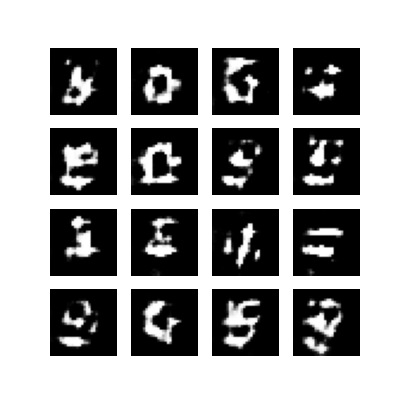



- /content/image_at_epoch_0010.png
Displaying /content/image_at_epoch_0010.png:


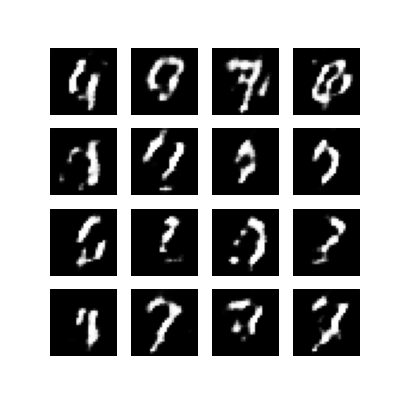



- /content/image_at_epoch_0015.png
Displaying /content/image_at_epoch_0015.png:


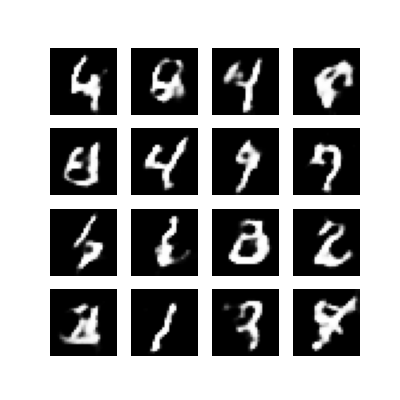



- /content/image_at_epoch_0020.png
Displaying /content/image_at_epoch_0020.png:


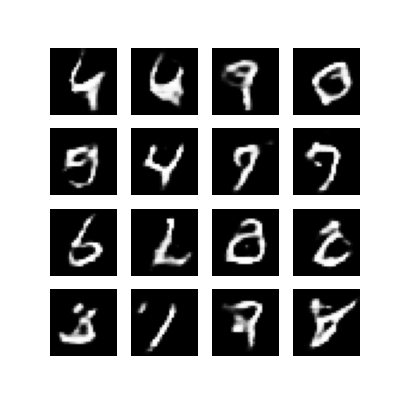



- /content/image_at_epoch_0025.png
Displaying /content/image_at_epoch_0025.png:


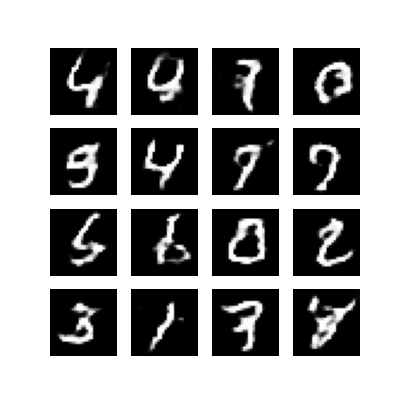



- /content/image_at_epoch_0030.png
Displaying /content/image_at_epoch_0030.png:


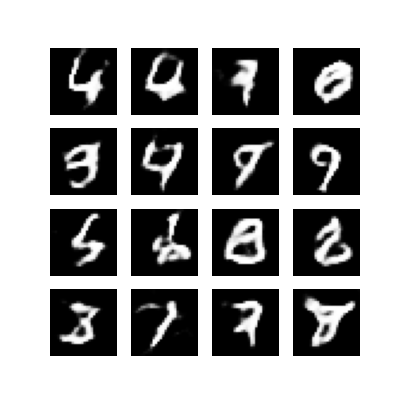



- /content/image_at_epoch_0035.png
Displaying /content/image_at_epoch_0035.png:


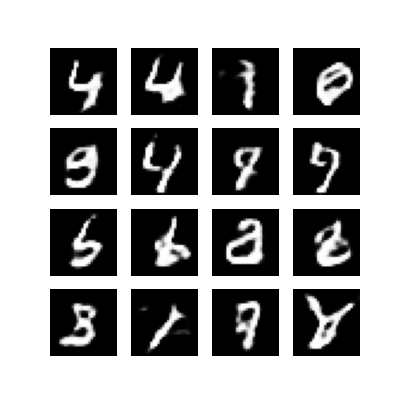



- /content/image_at_epoch_0040.png
Displaying /content/image_at_epoch_0040.png:


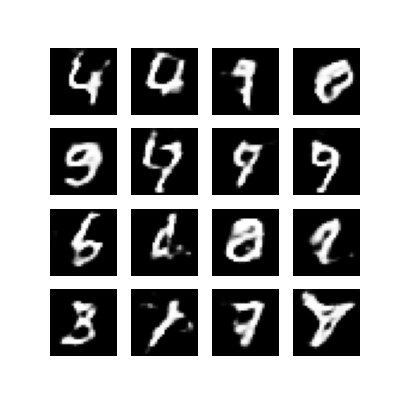



- /content/image_at_epoch_0045.png
Displaying /content/image_at_epoch_0045.png:


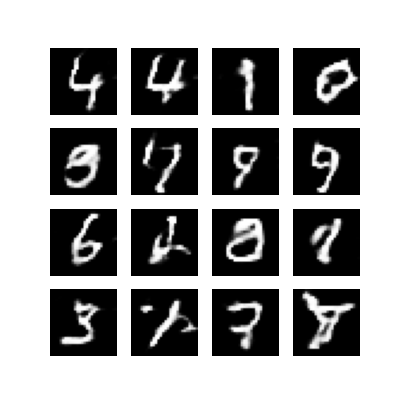



- /content/image_at_epoch_0050.png
Displaying /content/image_at_epoch_0050.png:


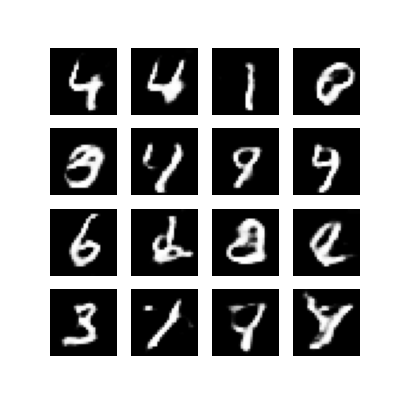

In [ ]:
import glob
from IPython.display import Image, display

# Encontrar todos os arquivos .png no diretório /content
image_files = glob.glob('/content/*.png')
image_files.sort()

if image_files:
    print("Arquivos .png encontrados no /content:")
    for img_file in image_files:
        print(f"- {img_file}")
        print(f"Displaying {img_file}:")
        display(Image(filename=img_file))
        print("\n")
else:
    print("Nenhum arquivo .png encontrado no diretório /content.")